# libary imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from libs.train.dataframe_splitter import split_dataframe, select_features
from sklearn.model_selection import cross_val_score
import optuna
import os

C:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Gesplitste data ophalen

In [2]:
raw_data = pd.read_csv('data/train_set.csv')
target = pd.read_csv('data/target_set.csv')
randomState = 42

x, y = split_dataframe(raw_data, target)
X_new = select_features(x, y, 195)

# functie definities
functies gedefineerd om uiteindelijk model te kunnen beschrijven

In [3]:
def explain_tree(model, x, amount= 15):
	# Assuming 'clf' is your trained model and 'X_train' is a pandas DataFrame
	importances = model.feature_importances_
	feature_names = x.train.columns

	# Create a pandas Series for easy plotting
	feature_importance_series = pd.Series(importances, index=feature_names)

	# Plot
	plt.figure(figsize=(10, 6))
	feature_importance_series.nlargest(amount).plot(kind='barh')
	plt.title(f"Top {amount} Most Important Features")
	plt.xlabel("Importance (Mean Decrease in Impurity)")
	plt.show()

def show_confusion(y, y_pred):
	cm = confusion_matrix(y_true=y, y_pred=y_pred)
	disp = ConfusionMatrixDisplay(confusion_matrix=cm)
	disp.plot()
	plt.show()

def print_accuracy(y, y_pred):
	score = accuracy_score(
		y_true=y,
		y_pred=y_pred
	)
	print(f"accuracy: {score}")

def print_f1score(y, y_pred):
	print(f"f1Score: {get_f1score(y, y_pred)}")

def get_f1score(y, y_pred):
	return f1_score(
		y_true=y,
		y_pred=y_pred
	)

# functie definities
functies gedefineerd die gebruikt worden tijdens het trainen van het model

In [4]:
csv_bestandsnaam = "data/optuna_save_forest_inbetween.csv"
def readfile():
	try:
		return pd.read_csv(csv_bestandsnaam)
	except FileNotFoundError:
		print(f"{csv_bestandsnaam} file not found.")
		return None

def savefile(df):
	df.to_csv(csv_bestandsnaam, index=True)

def getBestParams(oldResults):
    oldResults = oldResults.sort_values(by='value', ascending=False)
    bestOldTrial = oldResults.iloc[0]
    
    return {
        'max_depth': int(bestOldTrial['params_max_depth']),
        'min_samples_leaf': int(bestOldTrial['params_min_samples_leaf']),
        'min_samples_split': int(bestOldTrial['params_min_samples_split']),
        'max_leaf_nodes': int(bestOldTrial['params_max_leaf_nodes']),
        'max_features': int(bestOldTrial['params_max_features'])
    }


def shouldStop(study):
	bestCount = 0
	bestparams = None
	stopThreshold = 20

	if bestparams == study.best_params:
		bestCount += 10
		if bestCount >= stopThreshold:
			return True
		else:
			bestCount=10
			bestparams == study.best_params
	return False

def closureShouldStop(stopThreshold=500, step=10):
	bestCount = 0
	bestParams = None
	stopThreshold = stopThreshold
	step=step

	def shouldStop(study):
		nonlocal bestCount, bestParams, stopThreshold
		reset = False

		if bestParams == study.best_params:
			bestCount += step
			if bestCount >= stopThreshold:
				return True, bestCount, reset
		else:
			reset = True
			bestCount = step
			bestParams = study.best_params
			
		return False, bestCount, reset
	return shouldStop

def get_storage_name(relative_path):
	full_path = os.path.abspath(relative_path)
	database_map = os.path.dirname(full_path)
	os.makedirs(database_map, exist_ok=True)
	return f"sqlite:///{full_path}"

# closure voor een trail
in onderstaande functie setupObj kunnen variabelen in scope opgeslagen worden die in de teruggegeven functie objective dan gebruikt worden. Hierdoor is het mogelijk de object functie te hergebruiken in plaats van steeds een nieuwe te schrijven aangezien de objective functie niet meer dan 1 variabel krijgt van Optuna.

In [5]:
def setupObj(cv_in, estimators_in = 10):
	cv = cv_in
	estimators = estimators_in
	def objective(trial):
		nonlocal cv
		nonlocal estimators
		params = {
			'max_depth': trial.suggest_int('max_depth', 9, 12),
			'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 400),
			'min_samples_split': trial.suggest_int('min_samples_split', 5, 800),
			'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 100),
			'max_features': trial.suggest_int('max_features', 50, 195),
			'n_estimators': trial.suggest_int('n_estimators', estimators, estimators)
		}
		
		model = RandomForestClassifier(random_state=42, **params)
		
		score = cross_val_score(model, X_new.train, y.train["in2022"], cv=cv, scoring='f1', n_jobs=1).mean()
		return score
	
	return objective

# training 1
In de onderstaande code wordt het model initieel getraint op een snelle en niet accurate manier. Hierdoor worden de grootste trainlast zo snel mogelijk afgerond en kan hierna er preciezer getraint worden. Een trial heeft in deze sessies 1 boom en 2voud crossvalidatie.

In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
step = 50
stopThreshold = 150
shouldStop = closureShouldStop(stopThreshold=stopThreshold, step=step)

for epoch in range(0, 6000, step):
	try:
		oldResults = readfile()
		storage_name = get_storage_name("data/optuna_data_forest.db")

		study = optuna.create_study(
			storage=storage_name,
			study_name="optuna_data_forest",
			direction='maximize',
			load_if_exists=True # Hervat de *nieuwe* studie als deze crasht
		)
		
		if oldResults is not None:
			study.enqueue_trial(getBestParams(oldResults))

		objective = setupObj(2, 1)
		study.optimize(objective, n_trials=step, n_jobs=-1)
		results_df = study.trials_dataframe()
		savefile(results_df)

		isEnding, bestCount, reset = shouldStop(study)
		print(f"Trial: {len(study.get_trials())}")
		print(f"bestCount: {bestCount}")
		if (reset):
			params = getBestParams(readfile())
			print(f"best_value: {study.best_value}")
			print(f"new beste params\n\t{params}")
		
		print()
		
		if isEnding:
			print(f"Study has completed: after {stopThreshold} runs no further runs where found")
			break
	
	except Exception as e:
		print(f"Een fout is opgetreden: {e}")

Trial: 596
bestCount: 50
best_value: 0.8496336441088843
new beste params
	{'max_depth': 12, 'min_samples_leaf': 11, 'min_samples_split': 10, 'max_leaf_nodes': 96, 'max_features': 195}

Trial: 646
bestCount: 100

Trial: 696
bestCount: 150

Study has completed: after 150 runs no further runs where found


# training 2
In de onderstaande code wordt het model op een precizere manier getraint een model heeft nu 10 bomen en 10x crossvalidatie per trial.

In [7]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
step = 5
stopThreshold = 100
shouldStop = closureShouldStop(stopThreshold=stopThreshold, step=step)

for epoch in range(0, 6000, step):
	try:
		oldResults = readfile()
		storage_name = get_storage_name("data/optuna_data_forest.db")

		study = optuna.create_study(
			storage=storage_name,
			study_name="optuna_data_forest",
			direction='maximize',
			load_if_exists=True # Hervat de *nieuwe* studie als deze crasht
		)
		
		if oldResults is not None:
			study.enqueue_trial(getBestParams(oldResults))

		objective = setupObj(10, 10)
		study.optimize(objective, n_trials=step, n_jobs=-1)
		results_df = study.trials_dataframe()
		savefile(results_df)

		isEnding, bestCount, reset = shouldStop(study)
		print(f"Trial: {len(study.get_trials())}")
		print(f"bestCount: {bestCount}")
		if (reset):
			params = getBestParams(readfile())
			print(f"best_value: {study.best_value}")
			print(f"new beste params\n\t{params}")
		
		print()
		
		if isEnding:
			print(f"Study has completed: after {stopThreshold} runs no further runs where found")
			break
	
	except Exception as e:
		print(f"Een fout is opgetreden: {e}")

Trial: 701
bestCount: 5
best_value: 0.8496336441088843
new beste params
	{'max_depth': 12, 'min_samples_leaf': 11, 'min_samples_split': 10, 'max_leaf_nodes': 96, 'max_features': 195}

Trial: 706
bestCount: 10

Trial: 711
bestCount: 15

Trial: 716
bestCount: 20

Trial: 721
bestCount: 25

Trial: 726
bestCount: 30

Trial: 731
bestCount: 35

Trial: 736
bestCount: 40

Trial: 741
bestCount: 45

Trial: 746
bestCount: 50

Trial: 751
bestCount: 55

Trial: 756
bestCount: 60

Trial: 761
bestCount: 65

Trial: 766
bestCount: 70

Trial: 771
bestCount: 75

Trial: 776
bestCount: 80

Trial: 781
bestCount: 85

Trial: 786
bestCount: 90

Trial: 791
bestCount: 95

Trial: 796
bestCount: 100

Study has completed: after 100 runs no further runs where found


# train sessie 3
In onderstaande trainsessie wordt getraint per trial getraint op 100 bomen en een 3voud crossvalidatie.
Het doel hiervan is de betrouwbaarheid in de accuraatheid van het model te maximaliseren.

In [8]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
step = 5
stopThreshold = 25
shouldStop = closureShouldStop(stopThreshold=stopThreshold, step=step)

for epoch in range(0, 300, step):
	try:
		oldResults = readfile()
		storage_name = get_storage_name("data/optuna_data_forest.db")

		study = optuna.create_study(
			storage=storage_name,
			study_name="optuna_data_forest",
			direction='maximize',
			load_if_exists=True # Hervat de *nieuwe* studie als deze crasht
		)
		
		if oldResults is not None:
			study.enqueue_trial(getBestParams(oldResults))

		objective = setupObj(3, 100)
		study.optimize(objective, n_trials=step, n_jobs=-1)
		results_df = study.trials_dataframe()
		savefile(results_df)

		isEnding, bestCount, reset = shouldStop(study)
		print(f"Trial: {len(study.get_trials())}")
		print(f"bestCount: {bestCount}")
		if (reset):
			params = getBestParams(readfile())
			print(f"best_value: {study.best_value}")
			print(f"new beste params\n\t{params}")
		
		print()
		
		if isEnding:
			print(f"Study has completed: after {stopThreshold} runs no further runs where found")
			break
	
	except Exception as e:
		print(f"Een fout is opgetreden: {e}")

Trial: 801
bestCount: 5
best_value: 0.8496336441088843
new beste params
	{'max_depth': 12, 'min_samples_leaf': 11, 'min_samples_split': 10, 'max_leaf_nodes': 96, 'max_features': 195}

Trial: 806
bestCount: 10

Trial: 811
bestCount: 15

Trial: 816
bestCount: 20

Trial: 821
bestCount: 25

Study has completed: after 25 runs no further runs where found


# definitief model
Na het tunen van de hyper parameters wordt nu het definitieve model getraint.

In [9]:
m = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=12, min_samples_leaf=11, min_samples_split=10, max_leaf_nodes=96, max_features=195)
m.fit(X=X_new.train, y=y.train['in2022'])

,n_estimators,500
,criterion,'gini'
,max_depth,12
,min_samples_split,10
,min_samples_leaf,11
,min_weight_fraction_leaf,0.0
,max_features,195
,max_leaf_nodes,96
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Prestatie checks
Als laatst wordt er informatie uit het model gehaald om te zien hoe het model presteerd.

features: 195
leaves: 96
accuracy: 0.9441387108933283
f1Score: 0.6473108043788672


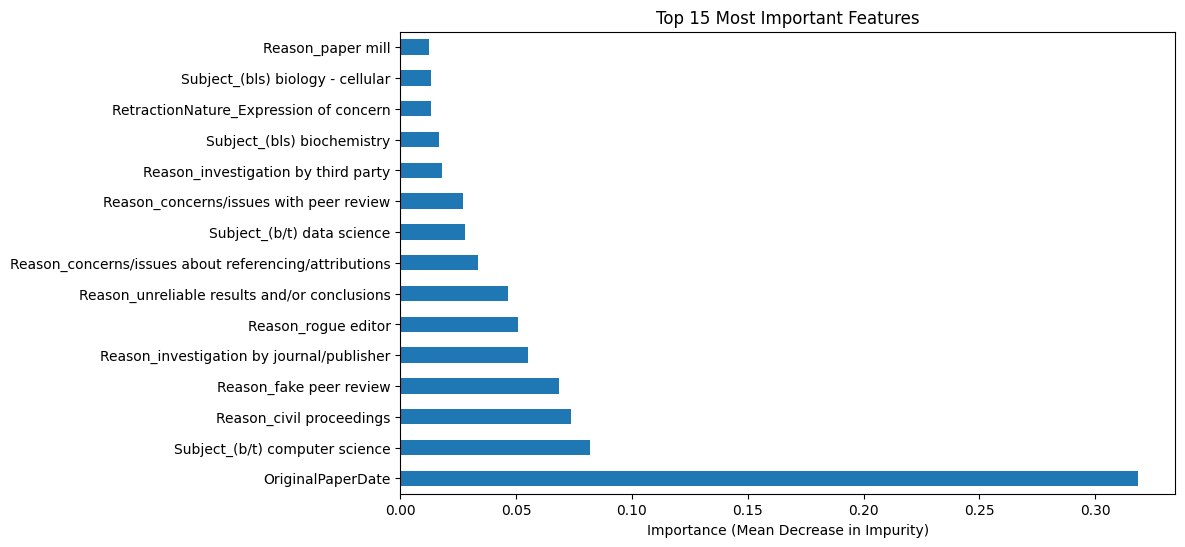

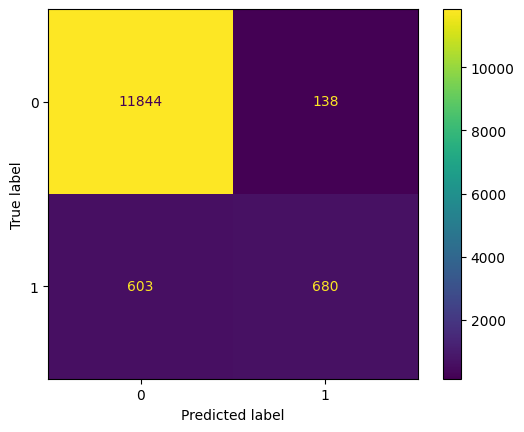

In [10]:
y_pred = m.predict(X=X_new.val)

print(f"features: {m.n_features_in_}")
print(f"leaves: {m.max_leaf_nodes}")
print_accuracy(y.val, y_pred)
print_f1score(y.val, y_pred)
explain_tree(m, X_new, 15)
show_confusion(y.val, y_pred)